In [ ]:
# загрузка библиотек

# методы для отрисовки изображений
from PIL import Image

# Для отрисовки графиков
import matplotlib.pyplot as plt

# Для генерации случайных чисел
import random

# Библиотека работы с массивами
import numpy as np

# Для работы с файлами
import os

# импортируем модуль для загрузки данных
import gdown

# для разделения выборок
from sklearn.model_selection import train_test_split

# для создания сети
from tensorflow.keras.models import Sequential

# для создания слоев
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization

# для работы с изображениями
from tensorflow.keras.preprocessing import image

# оптимизатор
from tensorflow.keras.optimizers import Adam

# модуль для отсчета времени
import time

In [ ]:
# загрузка датасета, укажем путь к базе в Google Drive, база в виде .zip-архива
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip', None, quiet=True)

# Распакуем архив в директорию 'content/bus'
!unzip -q "bus.zip" -d /content/bus

# Папка с папками картинок, рассортированных по категориям
IMAGE_PATH = '/content/bus/'

# Получение списка папок, находящемуся по адресу в скобках
os.listdir(IMAGE_PATH)

['Входящий', 'Выходящий']

In [ ]:
# Определение списка имен классов
CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

# Проверка результата
print(f'Количество классов: {CLASS_COUNT}, метки классов: {CLASS_LIST}')

Количество классов: 2, метки классов: ['Входящий', 'Выходящий']


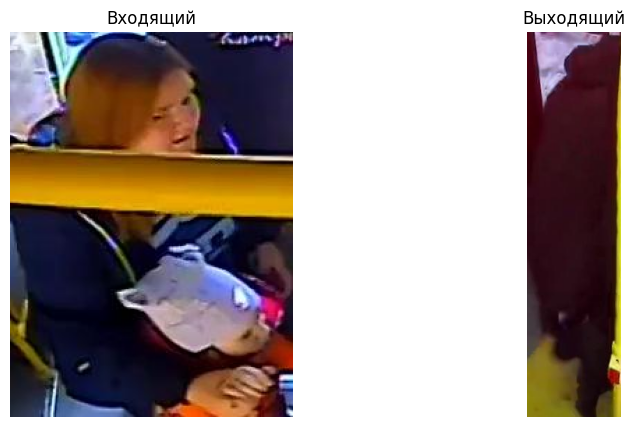

In [ ]:
# Создание заготовки для изображений всех классов
fig, axs = plt.subplots(1, CLASS_COUNT, figsize=(10, 5))

# Для всех номеров классов:
for i in range(CLASS_COUNT):

    # Формирование пути к папке содержимого класса
    car_path = f'{IMAGE_PATH}{CLASS_LIST[i]}/'

    # Выбор случайного фото из i-го класса
    img_path = car_path + random.choice(os.listdir(car_path))

    # Отображение фотографии (подробнее будет объяснено далее)
    axs[i].set_title(CLASS_LIST[i])
    axs[i].imshow(Image.open(img_path))
    axs[i].axis('off')

# Отрисовка всего полотна
plt.show()

In [ ]:
data_files = []                           # Cписок путей к файлам картинок
data_labels = []                          # Список меток классов, соответствующих файлам

for class_label in range(CLASS_COUNT):    # Для всех классов по порядку номеров (их меток)
    class_name = CLASS_LIST[class_label]  # Выборка имени класса из списка имен
    class_path = IMAGE_PATH + class_name  # Формирование полного пути к папке с изображениями класса
    class_files = os.listdir(class_path)  # Получение списка имен файлов с изображениями текущего класса
    print(f'Размер класса {class_name} составляет {len(class_files)} фото')

    # Добавление к общему списку всех файлов класса с добавлением родительского пути
    data_files += [f'{class_path}/{file_name}' for file_name in class_files]

    # Добавление к общему списку меток текущего класса - их ровно столько, сколько файлов в классе
    data_labels += [class_label] * len(class_files)

print()
print('Общий размер базы для обучения:', len(data_labels))

Размер класса Входящий составляет 6485 фото
Размер класса Выходящий составляет 2596 фото

Общий размер базы для обучения: 9081


In [ ]:
from sklearn.model_selection import train_test_split
x_train_rem,x_test,y_train_rem,y_test=train_test_split(data_files,data_labels,test_size=0.1,random_state=42,stratify=data_labels)
x_train,x_val,y_train,y_val=train_test_split(x_train_rem,y_train_rem,test_size=0.1,random_state=42,stratify=y_train_rem)

In [ ]:
model=Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.2),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])
opt=Adam(learning_rate=0.001)
model.compile(optimizer=opt,
              loss='MSE',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history=model.fit(x_train,
                  y_train,
                  validation_data=(x_val,y_val),
                  batch_size=128,
                  epochs=10,
                  verbose=1)

ValueError: Unrecognized data type: x=['/content/bus/Выходящий/02174.jpg', '/content/bus/Входящий/04895.jpg', '/content/bus/Входящий/04181.jpg', '/content/bus/Выходящий/01033.jpg', '/content/bus/Входящий/01756.jpg', '/content/bus/Выходящий/02111.jpg', '/content/bus/Входящий/02795.jpg', '/content/bus/Входящий/01679.jpg', '/content/bus/Выходящий/01468.jpg', '/content/bus/Входящий/02615.jpg', '/content/bus/Выходящий/01769.jpg', '/content/bus/Входящий/04281.jpg', '/content/bus/Входящий/04956.jpg', '/content/bus/Выходящий/02576.jpg', '/content/bus/Входящий/06353.jpg', '/content/bus/Входящий/01668.jpg', '/content/bus/Входящий/02429.jpg', '/content/bus/Входящий/03882.jpg', '/content/bus/Входящий/02334.jpg', '/content/bus/Входящий/03172.jpg', '/content/bus/Входящий/04324.jpg', '/content/bus/Входящий/02053.jpg', '/content/bus/Входящий/05224.jpg', '/content/bus/Выходящий/01748.jpg', '/content/bus/Выходящий/01325.jpg', '/content/bus/Входящий/01856.jpg', '/content/bus/Входящий/02562.jpg', '/conten